## converting json to df

In [1]:
import pandas as pd

In [2]:
df = pd.read_json("D:\Patent-Intelligence\merged.json")  
df.head(5)

,source_url,patent_id,title,title_en,abstract,abstract_en,description,claims,claims_en,filing_date,...,assignee_original,assignee_en,inventors,ipc_codes,cpc_codes,claim_count,independent_claim_count,backward_citation_count,forward_citation_count,legal_status
0,https://patents.google.com/patent/KR102798691B...,KR102798691B1,Electrocardiogram interpretating system with u...,Electrocardiogram interpretating system with u...,The present invention comprises an electrocard...,The present invention comprises an electrocard...,The present invention comprises an electrocard...,1유도 이상의 심전도를 측정하여 심전도 데이터를 생성하는 심전도 측정부; 상기 1유...,1유도 이상의 심전도를 측정하여 심전도 데이터를 생성하는 심전도 측정부; 상기 1유...,2021-08-17,...,주식회사 메디컬에이아이,주식회사 메디컬에이아이,None,[A61B5/0006],[A61B5/0006],5,5,62,0,Status
1,https://patents.google.com/patent/US11913937B2/en,US11913937B2,Method and device for automatically tracking u...,Method and device for automatically tracking u...,A method of automatically tracking urine in a ...,A method of automatically tracking urine in a ...,CROSS-REFERENCE TO RELATED PATENT APPLICATIONS...,1. A method of automatically tracking urine in...,1. A method of automatically tracking urine in...,2021-08-13,...,Shanghai Kohler Electronics Ltd,Shanghai Kohler Electronics Ltd,None,[G01N33/493],[G01N33/493],20,3,81,0,Status
2,https://patents.google.com/patent/JP7095207B2/en,JP7095207B2,X-ray detector with independent sleepable proc...,X-ray detector with independent sleepable proc...,None,None,None,入射するＸ線に応答して複数の信号を生成するよう構成されるデジタルイメージセンサと、 前記デジ...,入射するＸ線に応答して複数の信号を生成するよう構成されるデジタルイメージセンサと、 前記デジ...,2019-11-05,...,ヴァレックス イメージング コーポレイション,ヴァレックス イメージング コーポレイション,None,"[G01N21/00, G01N23/04, G01N22/00, G01N17/00, G...","[G01N21/00, G01N23/04, G01N22/00, G01N17/00, G...",23,7,75,0,Status
3,https://patents.google.com/patent/CN108538402A/en,CN108538402A,"A kind of MDT consultation of doctors method, ...","A kind of MDT consultation of doctors method, ...",The present invention discloses a kind of MDT ...,The present invention discloses a kind of MDT ...,"A kind of MDT consultation of doctors method, ...","A kind of method 1. MDT holds a consultation, ...","A kind of method 1. MDT holds a consultation, ...",2018-04-16,...,Shenzhen Zero One Cloud Medical Science And Te...,Shenzhen Zero One Cloud Medical Science And Te...,None,[G16H80/00],[G16H80/00],10,2,57,0,Status
4,https://patents.google.com/patent/CN112908445A/en,CN112908445A,Diabetes patient blood sugar management method...,Diabetes patient blood sugar management method...,The invention provides a diabetes patient bloo...,The invention provides a diabetes patient bloo...,Diabetes patient blood sugar management method...,1. A diabetes patient blood sugar management m...,1. A diabetes patient blood sugar management m...,2021-02-20,...,Shanghai Fourth People's Hospital,Shanghai Fourth People's Hospital,None,[G16H20/10],[G16H20/10],9,2,32,0,Status


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   source_url               2000 non-null   object 
 1   patent_id                2000 non-null   object 
 2   title                    2000 non-null   object 
 3   title_en                 2000 non-null   object 
 4   abstract                 1862 non-null   object 
 5   abstract_en              1862 non-null   object 
 6   description              1862 non-null   object 
 7   claims                   2000 non-null   object 
 8   claims_en                2000 non-null   object 
 9   filing_date              2000 non-null   object 
 10  publication_date         2000 non-null   object 
 11  country                  2000 non-null   object 
 12  language                 0 non-null      float64
 13  assignee_original        2000 non-null   object 
 14  assignee_en             

In [4]:
df.columns

Index(['source_url', 'patent_id', 'title', 'title_en', 'abstract',
       'abstract_en', 'description', 'claims', 'claims_en', 'filing_date',
       'publication_date', 'country', 'language', 'assignee_original',
       'assignee_en', 'inventors', 'ipc_codes', 'cpc_codes', 'claim_count',
       'independent_claim_count', 'backward_citation_count',
       'forward_citation_count', 'legal_status'],
      dtype='object')

In [5]:
df.shape

(2000, 23)

### Missing Value Analysis

##

In [6]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': round((missing/len(df))*100,2)
})

print(missing_df)

                         Missing Count  Missing %
source_url                           0        0.0
patent_id                            0        0.0
title                                0        0.0
title_en                             0        0.0
abstract                           138        6.9
abstract_en                        138        6.9
description                        138        6.9
claims                               0        0.0
claims_en                            0        0.0
filing_date                          0        0.0
publication_date                     0        0.0
country                              0        0.0
language                          2000      100.0
assignee_original                    0        0.0
assignee_en                          0        0.0
inventors                         1996       99.8
ipc_codes                            0        0.0
cpc_codes                            0        0.0
claim_count                          0        0.0


### drop completely missing values

In [7]:
# Modify the original DataFrame directly
df.drop(columns=['language', 'inventors'], errors='ignore', inplace=True)
df.columns

Index(['source_url', 'patent_id', 'title', 'title_en', 'abstract',
       'abstract_en', 'description', 'claims', 'claims_en', 'filing_date',
       'publication_date', 'country', 'assignee_original', 'assignee_en',
       'ipc_codes', 'cpc_codes', 'claim_count', 'independent_claim_count',
       'backward_citation_count', 'forward_citation_count', 'legal_status'],
      dtype='object')

#### handling missing abstaracts

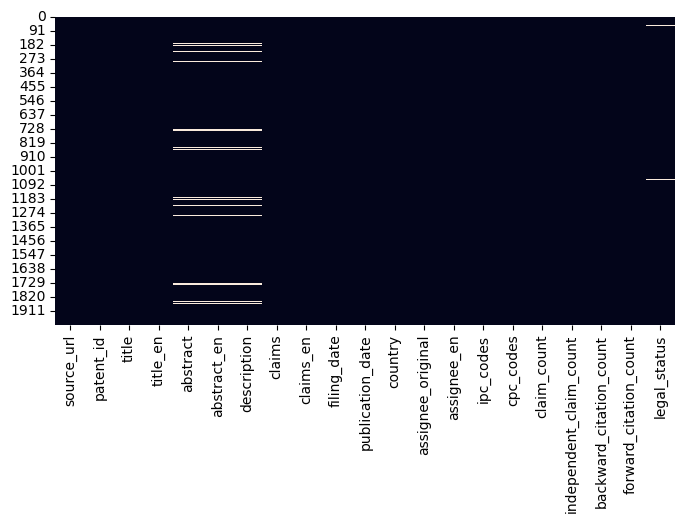

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

### Duplicate Analysis

In [9]:
# inspecting data types of columns
print(df.dtypes)

source_url                 object
patent_id                  object
title                      object
title_en                   object
abstract                   object
abstract_en                object
description                object
claims                     object
claims_en                  object
filing_date                object
publication_date           object
country                    object
assignee_original          object
assignee_en                object
ipc_codes                  object
cpc_codes                  object
claim_count                 int64
independent_claim_count     int64
backward_citation_count     int64
forward_citation_count      int64
legal_status               object
dtype: object


In [10]:
# checking type of values in each column
for col in df.columns:
    print(col, type(df[col].iloc[0]))

source_url <class 'str'>
patent_id <class 'str'>
title <class 'str'>
title_en <class 'str'>
abstract <class 'str'>
abstract_en <class 'str'>
description <class 'str'>
claims <class 'str'>
claims_en <class 'str'>
filing_date <class 'str'>
publication_date <class 'str'>
country <class 'str'>
assignee_original <class 'str'>
assignee_en <class 'str'>
ipc_codes <class 'list'>
cpc_codes <class 'list'>
claim_count <class 'numpy.int64'>
independent_claim_count <class 'numpy.int64'>
backward_citation_count <class 'numpy.int64'>
forward_citation_count <class 'numpy.int64'>
legal_status <class 'str'>


In [11]:
# finding duplicates using unique identifier patent_id
df.duplicated(subset='patent_id').sum()

np.int64(1000)

In [12]:
# Handle Missing Abstracts
df[df['abstract'].isnull()][['patent_id',
                             'title',
                             'description',
                             'claims']].head()

,patent_id,title,description,claims
2,JP7095207B2,X-ray detector with independent sleepable proc...,None,入射するＸ線に応答して複数の信号を生成するよう構成されるデジタルイメージセンサと、 前記デジ...
17,JP7229483B2,Skin patch devices and kits comprising skin pa...,None,複数のマイクロニードルを備えたマイクロニードルアレイと、 前記マイクロニードルに取り付けられ...
60,EP4419190B1,Systems for providing neurostimulation therapy...,None,"A system (1000, 2400, 2700) for providing a ne..."
67,EP3440618B1,Video-based asynchronous appointments for secu...,None,A computer-implemented method comprising: rece...
149,EP3980944B1,Method for determining an optimal drug dosing ...,None,Method implemented by a computer for determini...


In [13]:
# use english abstract if available
df['abstract'] = df['abstract'].fillna(df['abstract_en'])

In [14]:
# Since both abstract and abstract_en have the same missing count, some patents still won't have abstracts.

# For those remaining patents, use the first few hundred characters of the description:

df['abstract'] = df.apply(
    lambda row:
    row['description'][:1000]
    if pd.isna(row['abstract']) and pd.notna(row['description'])
    else row['abstract'],
    axis=1
)

In [15]:
# Handle Missing Descriptions
df['description'] = df['description'].fillna('')

In [16]:
df.isnull().sum()

source_url                   0
patent_id                    0
title                        0
title_en                     0
abstract                   138
abstract_en                138
description                  0
claims                       0
claims_en                    0
filing_date                  0
publication_date             0
country                      0
assignee_original            0
assignee_en                  0
ipc_codes                    0
cpc_codes                    0
claim_count                  0
independent_claim_count      0
backward_citation_count      0
forward_citation_count       0
legal_status                22
dtype: int64

## For classification and clustering, create a combined text field:

- Creating a combined text field is a standard preprocessing step in Natural Language Processing (NLP). It merges multiple text columns into a single string for each row.Why Use This Code?Prevents Errors: .fillna('') replaces missing values (NaN) with empty spaces so the concatenation does not return an error or result in a missing output.Consolidates Context: It groups all relevant textual data (title, abstract, and claims) into one place for the machine learning model to read.

- Why Use This Code?Prevents Errors: .fillna('') replaces missing values (NaN) with empty spaces so the concatenation does not return an error or result in a missing output.Consolidates Context: It groups all relevant textual data (title, abstract, and claims) into one place for the machine learning model to read.

- Key Use Cases
1. Maximizing Information Density for ClassificationIn patent or academic paper classification, looking at the title alone is not enough to understand the topic.The abstract provides the summary.The claims provide technical boundaries.Combining them gives your classifier (like BERT, Logistic Regression, or LightGBM) the complete context to predict the correct category or tag.

2. Creating Complete Embeddings for ClusteringClustering algorithms (like K-Means) group similar documents based on text embeddings.If you generate embeddings for each column separately, you look at data in silos.By feeding combined_text into a vectorizer (like TF-IDF or Sentence-Transformers), you create a single, high-dimensional vector that captures the entire essence of the document.

3. Improving Document Search and RetrievalIf you are building a search engine, searching across multiple distinct columns is computationally heavy. Searching a single combined_text field speeds up keyword matching and semantic search queries.

- To help tailor the next steps, let me know:What machine learning model or embedding technique (e.g., TF-IDF, BERT) do you plan to use?Are you facing any token length limits (since combining text can make strings very long)?Is this for patent data, academic papers, or another type of document?8 sitesCrafting Clean Narratives With NLP: A Deep Dive into Text Data Preprocessing with Python, Pandas…2 Dec 2023 — Filling Missing Values: The fillna() method is used to fill missing values with a specified placeholder (in this case, an empty st...Level Up CodingPart 6: Data Manipulation in String and Text Processing15 Feb 2026 — One thing to keep in mind: string operations on missing values (NaN) return NaN. They don't throw errors, which is good. But you n...MediumData Cleaning and Preprocessing: Top 15 Interview Questions and Answers for Data Scientists2 Dec 2024 — Explanation: The fillna() function replaces missing values with a specified value. Using the column mean ensures no empty spots, a...MediumShow all

In [17]:
# For classification and clustering, create a combined text field:
df['combined_text'] = (
    df['title'].fillna('') + ' ' +
    df['abstract'].fillna('') + ' ' +
    df['claims'].fillna('')
)

In [18]:
df.head(3)

,source_url,patent_id,title,title_en,abstract,abstract_en,description,claims,claims_en,filing_date,...,assignee_original,assignee_en,ipc_codes,cpc_codes,claim_count,independent_claim_count,backward_citation_count,forward_citation_count,legal_status,combined_text
0,https://patents.google.com/patent/KR102798691B...,KR102798691B1,Electrocardiogram interpretating system with u...,Electrocardiogram interpretating system with u...,The present invention comprises an electrocard...,The present invention comprises an electrocard...,The present invention comprises an electrocard...,1유도 이상의 심전도를 측정하여 심전도 데이터를 생성하는 심전도 측정부; 상기 1유...,1유도 이상의 심전도를 측정하여 심전도 데이터를 생성하는 심전도 측정부; 상기 1유...,2021-08-17,...,주식회사 메디컬에이아이,주식회사 메디컬에이아이,[A61B5/0006],[A61B5/0006],5,5,62,0,Status,Electrocardiogram interpretating system with u...
1,https://patents.google.com/patent/US11913937B2/en,US11913937B2,Method and device for automatically tracking u...,Method and device for automatically tracking u...,A method of automatically tracking urine in a ...,A method of automatically tracking urine in a ...,CROSS-REFERENCE TO RELATED PATENT APPLICATIONS...,1. A method of automatically tracking urine in...,1. A method of automatically tracking urine in...,2021-08-13,...,Shanghai Kohler Electronics Ltd,Shanghai Kohler Electronics Ltd,[G01N33/493],[G01N33/493],20,3,81,0,Status,Method and device for automatically tracking u...
2,https://patents.google.com/patent/JP7095207B2/en,JP7095207B2,X-ray detector with independent sleepable proc...,X-ray detector with independent sleepable proc...,None,None,,入射するＸ線に応答して複数の信号を生成するよう構成されるデジタルイメージセンサと、 前記デジ...,入射するＸ線に応答して複数の信号を生成するよう構成されるデジタルイメージセンサと、 前記デジ...,2019-11-05,...,ヴァレックス イメージング コーポレイション,ヴァレックス イメージング コーポレイション,"[G01N21/00, G01N23/04, G01N22/00, G01N17/00, G...","[G01N21/00, G01N23/04, G01N22/00, G01N17/00, G...",23,7,75,0,Status,X-ray detector with independent sleepable proc...


### 

### Check for completely empty documents:

In [19]:
empty_docs = df['combined_text'].str.strip().eq('').sum()

print("Empty documents:", empty_docs)

Empty documents: 0


In [20]:
# Remove patents with no useful text
df = df[~(
    df['abstract'].isna() &
    (df['claims'].str.strip() == '')
)]

In [21]:
df.isnull().sum()

source_url                   0
patent_id                    0
title                        0
title_en                     0
abstract                   138
abstract_en                138
description                  0
claims                       0
claims_en                    0
filing_date                  0
publication_date             0
country                      0
assignee_original            0
assignee_en                  0
ipc_codes                    0
cpc_codes                    0
claim_count                  0
independent_claim_count      0
backward_citation_count      0
forward_citation_count       0
legal_status                22
combined_text                0
dtype: int64

### Basic Text statistics

- Patent documents often contain scraping errors or outliers

In [22]:
# abstract length
df['abstract_length'] = (
    df['abstract']
    .fillna('')
    .apply(len)
)

df['abstract_length'].describe()


count    2000.000000
mean      887.983000
std       403.102809
min         0.000000
25%       671.500000
50%       923.000000
75%      1147.250000
max      3184.000000
Name: abstract_length, dtype: float64

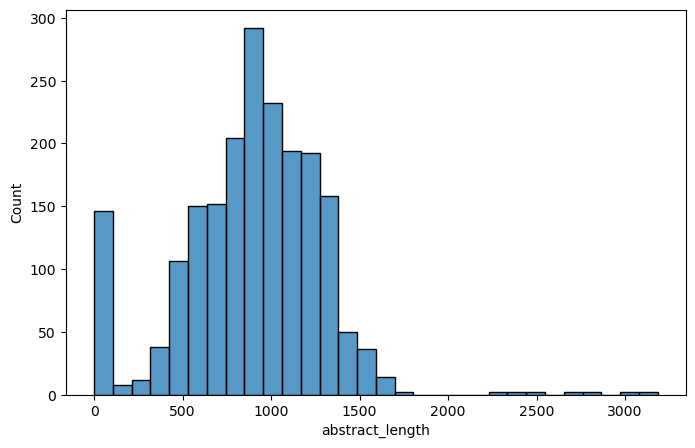

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['abstract_length'], bins=30)
plt.show()

In [24]:
# word count in abstract
df['word_count'] = df['abstract'].astype(str).apply(
    lambda x: len(x.split())
)

df['word_count'].describe()

count    2000.000000
mean      133.221000
std        60.293995
min         1.000000
25%       102.000000
50%       142.000000
75%       170.000000
max       525.000000
Name: word_count, dtype: float64

In [25]:
# claim characters length per patent
df['claims_length_chars'] = df['claims'].fillna('').apply(len)

df[['patent_id', 'claims_length_chars']]

,patent_id,claims_length_chars
0,KR102798691B1,4798
1,US11913937B2,6604
2,JP7095207B2,10617
3,CN108538402A,7737
4,CN112908445A,8004
...,...,...
1995,CN109961847A,6312
1996,US20160262681A1,8478
1997,US11944448B2,4692
1998,CN115996668B,5153


- Patent Intelligence project, I recommend using claims_word_count because it can later be used as:

An EDA feature
An ML feature
A complexity indicator
A patent quality indicator (along with citation counts)

In [26]:
# claim words length per patent
df['claims_word_count'] = (
    df['claims']
    .fillna('')
    .apply(lambda x: len(str(x).split()))
)

df[['patent_id', 'claims_word_count']]

,patent_id,claims_word_count
0,KR102798691B1,755
1,US11913937B2,1097
2,JP7095207B2,1306
3,CN108538402A,1114
4,CN112908445A,1242
...,...,...
1995,CN109961847A,929
1996,US20160262681A1,1418
1997,US11944448B2,763
1998,CN115996668B,807


In [27]:
# claims length
df['claims_length'] = \
df['claims'].astype(str).apply(len)

df['claims_length'].describe()

count     2000.000000
mean      9220.022000
std       5446.397031
min        402.000000
25%       5685.250000
50%       7966.000000
75%      11406.500000
max      66483.000000
Name: claims_length, dtype: float64

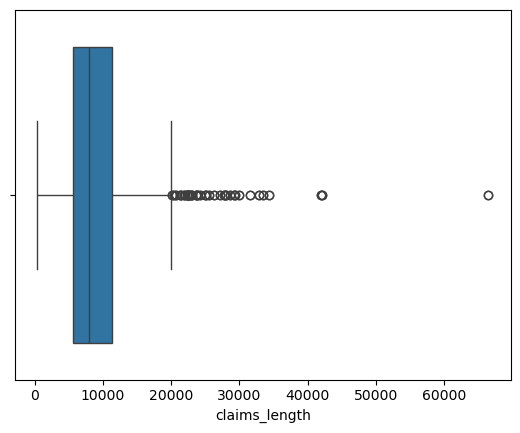

In [28]:
sns.boxplot(x=df['claims_length'])
plt.show()

### converting dates 

In [29]:
df['publication_date'] = pd.to_datetime(
    df['publication_date']
)
df['publication_date']

# df['year'] = df['publication_date'].dt.year
# df['year']

0      2023-02-24
1      2021-12-02
2      2020-05-28
3      2018-09-14
4      2021-06-04
          ...    
1995   2019-07-02
1996   2016-09-15
1997   2023-02-09
1998   2023-04-21
1999   2022-11-29
Name: publication_date, Length: 2000, dtype: datetime64[ns]

In [30]:
# filing date
df['filing_date'] = pd.to_datetime( df['filing_date'])
df['filing_year'] = df['filing_date'].dt.year
df[['filing_date', 'filing_year']]



,filing_date,filing_year
0,2021-08-17,2021
1,2021-08-13,2021
2,2019-11-05,2019
3,2018-04-16,2018
4,2021-02-20,2021
...,...,...
1995,2019-03-20,2019
1996,2015-03-13,2015
1997,2022-10-05,2022
1998,2022-11-23,2022


### Top assignees
- this provides competitor intelligence

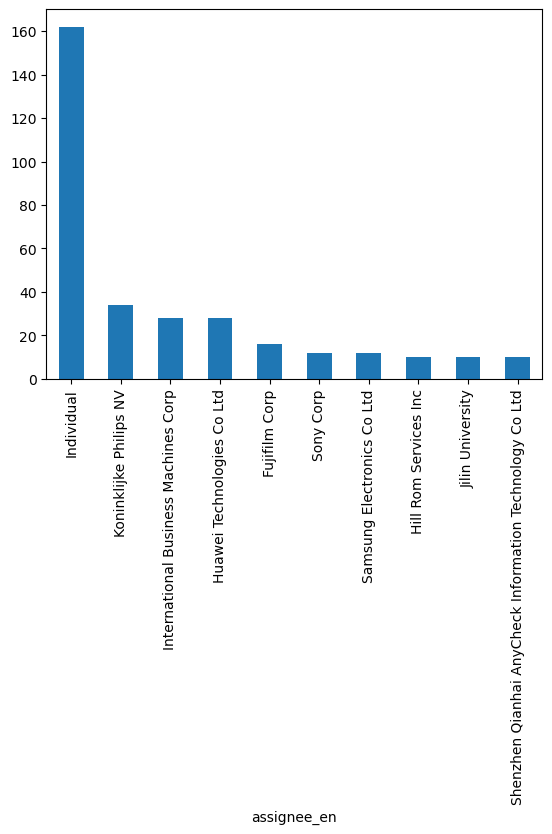

In [31]:
top_companies = df['assignee_en'].value_counts().head(10)

top_companies.plot(kind='bar')
plt.show()

### Text EDA

In [32]:
# most frequent words in abstract - These can later be added to custom stopwords.
text = " ".join(df['abstract'].astype(str))
text

from collections import Counter

words = text.lower().split()

Counter(words).most_common(30)

[('the', 24524),
 ('a', 13402),
 ('and', 10884),
 ('of', 9454),
 ('to', 7456),
 ('is', 3320),
 ('for', 3274),
 ('data', 2744),
 ('in', 2582),
 ('an', 2552),
 ('medical', 2418),
 ('information', 2174),
 ('on', 2142),
 ('by', 1814),
 ('user', 1718),
 ('system', 1628),
 ('with', 1520),
 ('patient', 1480),
 ('method', 1424),
 ('that', 1342),
 ('based', 1280),
 ('first', 1276),
 ('or', 1256),
 ('device', 1212),
 ('from', 1202),
 ('one', 1198),
 ('invention', 1186),
 ('at', 1124),
 ('be', 1074),
 ('can', 1038)]

In [33]:
# most frequent words in abstract - These can later be added to custom stopwords.
claims_text = " ".join(df['claims'].astype(str))
claims_text

from collections import Counter

words = claims_text.lower().split()

Counter(words).most_common(30)

[('the', 279150),
 ('of', 107504),
 ('a', 93838),
 ('and', 69354),
 ('to', 68198),
 ('is', 37194),
 ('in', 29128),
 ('data', 24636),
 ('wherein', 23302),
 ('for', 22788),
 ('상기', 21962),
 ('claim', 21182),
 ('one', 21018),
 ('information', 20676),
 ('or', 20034),
 ('on', 18262),
 ('by', 17266),
 ('an', 17142),
 ('medical', 16800),
 ('first', 15724),
 ('at', 15384),
 ('user', 15018),
 ('method', 14360),
 ('with', 14316),
 ('patient', 13548),
 ('according', 13326),
 ('system', 12498),
 (',', 12404),
 ('from', 12294),
 ('second', 11816)]

In [34]:
!pip install wordcloud

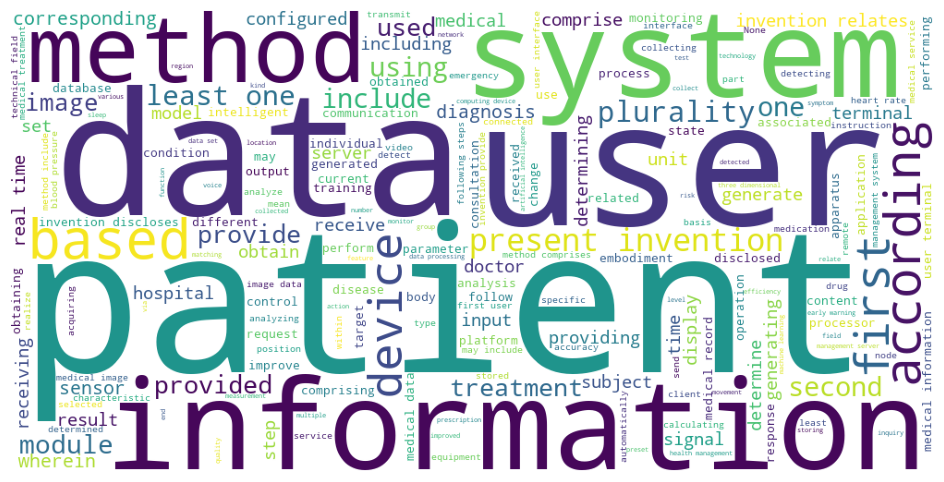

In [35]:

from wordcloud import WordCloud

wc = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis('off')
plt.show()

### Word Count Analysis

In [36]:
df['word_count'] = (
    df['combined_text']
    .apply(lambda x: len(str(x).split()))
)

df['word_count'].describe()

count     2000.000000
mean      1566.958000
std        867.176449
min        190.000000
25%       1014.000000
50%       1394.000000
75%       1896.250000
max      13091.000000
Name: word_count, dtype: float64

### Detect Outliers

In [37]:
# Find extremely short patents
short_patents = df[df['word_count'] < 50][
    ['patent_id',
     'title',
     'word_count']
]

short_patents

,patent_id,title,word_count


In [38]:
# find extremely long patents
df.nlargest(10, 'word_count')[
    ['patent_id',
     'title',
     'word_count']
]

,patent_id,title,word_count
527,WO2021210966A1,Method and device for automatically detecting ...,13091
1527,WO2021210966A1,Method and device for automatically detecting ...,13091
22,US20220003785A1,Methods for targeted assessment and treatment ...,6925
1022,US20220003785A1,Methods for targeted assessment and treatment ...,6925
711,US20250016521A1,"Systems and methods for trigger risk, substanc...",6097
1711,US20250016521A1,"Systems and methods for trigger risk, substanc...",6097
685,US11284238B1,"Emergency signs early detection, alert and res...",5051
1685,US11284238B1,"Emergency signs early detection, alert and res...",5051
546,DE102017203299B4,System and method for cardioembolic stroke ris...,4934
1546,DE102017203299B4,System and method for cardioembolic stroke ris...,4934


In [39]:
# For patent NLP, documents with fewer than 20 to 30 words are usually not useful and can often be removed.
df = df[df['word_count'] >= 30]

In [40]:
# analyze top assignees
df['assignee_en'].value_counts().head(15)

assignee_en
Individual                                                 162
Koninklijke Philips NV                                      34
International Business Machines Corp                        28
Huawei Technologies Co Ltd                                  28
Fujifilm Corp                                               16
Sony Corp                                                   12
Samsung Electronics Co Ltd                                  12
Hill Rom Services Inc                                       10
Jilin University                                            10
Shenzhen Qianhai AnyCheck Information Technology Co Ltd     10
연세대학교 산학협력단                                                 10
Shenzhen Mindray Bio Medical Electronics Co Ltd              8
서울대학교산학협력단                                                   8
Siemens Healthcare GmbH                                      8
E Techno Information Technologies Co Ltd                     8
Name: count, dtype: int64

In [41]:
# analyze legal status
df['legal_status'].value_counts()

legal_status
Status        1886
2018-03-12       4
2022-10-21       2
2019-04-25       2
2022-06-27       2
2021-03-12       2
2018-10-01       2
2020-05-03       2
2019-09-25       2
2024-09-22       2
2020-04-11       2
2018-07-08       2
2023-07-06       2
2021-06-04       2
2018-02-17       2
2021-02-28       2
2021-09-28       2
2019-01-29       2
2020-04-14       2
2017-09-23       2
2019-06-01       2
2020-09-05       2
2022-10-16       2
2024-01-29       2
2022-03-20       2
Active           2
2018-10-26       2
2021-06-13       2
2020-04-30       2
2018-12-21       2
2018-09-29       2
2020-05-23       2
2021-05-02       2
2019-05-29       2
Ceased           2
2022-10-07       2
2020-09-28       2
2025-06-29       2
2020-01-29       2
2018-11-18       2
2023-07-22       2
2020-10-11       2
2020-04-20       2
2024-10-22       2
2018-05-17       2
2018-02-12       2
Name: count, dtype: int64

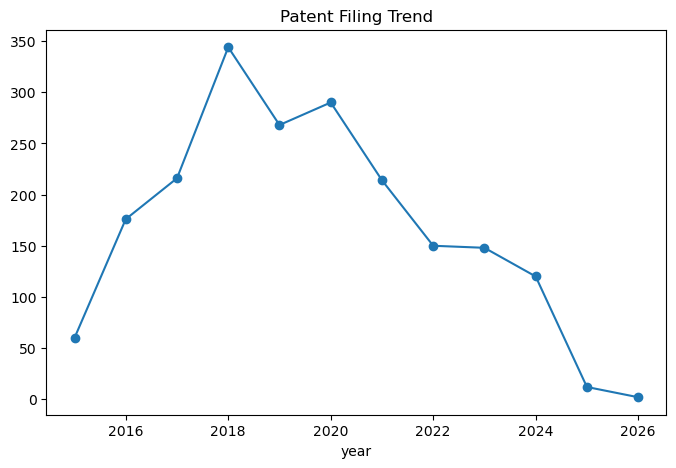

In [42]:
# analyze filing trends
df['filing_date'] = pd.to_datetime(df['filing_date'])

df['year'] = df['filing_date'].dt.year

df['year'].value_counts().sort_index().plot(
    kind='line',
    figsize=(8,5),
    marker='o'
)

plt.title('Patent Filing Trend')
plt.show()

### analyzing ipc/cpc codes

In [43]:
# Analyze CPC codes frequency
from collections import Counter

all_cpc = []

for codes in df['cpc_codes']:
    all_cpc.extend(codes)

Counter(all_cpc).most_common(10)

[('G16H80/00', 174),
 ('A61B5/00', 156),
 ('G16H40/20', 72),
 ('G16H50/20', 72),
 ('G16H10/60', 68),
 ('G16H50/30', 52),
 ('G16H20/10', 42),
 ('G16H20/70', 36),
 ('G16H40/67', 36),
 ('G16H10/20', 34)]


### why we are analyzingg cpc codes
This is an excellent idea for EDA. In patent analytics, it is very common to analyze patents at two levels:

1. **Parent CPC class level** (high-level technology domains)
2. **Subcategory CPC code level** (specific technologies)

For example:

```text
A61B → 250 patents
    A61B5/00 → 120 patents
    A61B5/024 → 60 patents
    A61B34/00 → 40 patents

G16H → 180 patents
    G16H50/20 → 80 patents
    G16H50/30 → 50 patents
    G16H40/60 → 30 patents
```



In [45]:
# count parent cpc classes
# Extract the parent class from each CPC code.
from collections import Counter

parent_classes = []

for patent_codes in df['cpc_codes']:
    for code in patent_codes:

        # Extract parent class
        parent = code.split('/')[0]

        # For G16H50/20 -> G16H
        if len(parent) > 4:
            parent = parent[:4]

        parent_classes.append(parent)

parent_count = Counter(parent_classes)

print(parent_count.most_common())


[('G16H', 844), ('A61B', 504), ('G06F', 162), ('G06Q', 112), ('G01N', 40), ('H04L', 32), ('G06T', 28), ('G06N', 24), ('G08B', 22), ('A61N', 20), ('A63B', 18), ('A61C', 16), ('A61J', 14), ('G06V', 14), ('A61M', 14), ('G06K', 14), ('H04M', 10), ('A61F', 10), ('G01S', 10), ('A61H', 8), ('G10L', 8), ('H04N', 6), ('G09B', 6), ('H04W', 6), ('B60W', 6), ('G16Z', 4), ('G02C', 4), ('H04Q', 4), ('A41D', 4), ('A01K', 4), ('G16B', 4), ('H04B', 4), ('A45D', 4), ('C12Q', 4), ('G01L', 4), ('G02B', 2), ('A47C', 2), ('H01G', 2), ('G16C', 2), ('H05K', 2), ('G01G', 2), ('H01L', 2), ('H03F', 2), ('G05D', 2), ('G10K', 2), ('G07F', 2), ('A41F', 2), ('G07C', 2), ('A61G', 2), ('A61L', 2), ('B25J', 2), ('A42B', 2), ('H04R', 2)]


### Create Technology Categories Automatically

In [53]:
# mapping cpc codes to categories
category_map = {

'A61B5/00':'Diagnostic Devices',
'A61B5/024':'Wearables',
'G16H50/00':'Remote Monitoring',
'G06N20/00':'AI-enabled Devices',
'A61M':'Surgical Devices'
}

In [ ]:
def assign_category(cpc_list):

    for code in cpc_list:

        if code in category_map:
            return category_map[code]

    return 'Other'


df['technology_class'] = df['cpc_codes'].apply(assign_category)
df['technology_class'].head(20)

0    Other
1    Other
2    Other
3    Other
4    Other
Name: technology_class, dtype: object

In [58]:
df.head(30)

,source_url,patent_id,title,title_en,abstract,abstract_en,description,claims,claims_en,filing_date,...,legal_status,combined_text,abstract_length,word_count,claims_length_chars,claims_word_count,claims_length,filing_year,year,technology_class
0,https://patents.google.com/patent/KR102798691B...,KR102798691B1,Electrocardiogram interpretating system with u...,Electrocardiogram interpretating system with u...,The present invention comprises an electrocard...,The present invention comprises an electrocard...,The present invention comprises an electrocard...,1유도 이상의 심전도를 측정하여 심전도 데이터를 생성하는 심전도 측정부; 상기 1유...,1유도 이상의 심전도를 측정하여 심전도 데이터를 생성하는 심전도 측정부; 상기 1유...,2021-08-17,...,Status,Electrocardiogram interpretating system with u...,1352,943,4798,755,4798,2021,2021,Other
1,https://patents.google.com/patent/US11913937B2/en,US11913937B2,Method and device for automatically tracking u...,Method and device for automatically tracking u...,A method of automatically tracking urine in a ...,A method of automatically tracking urine in a ...,CROSS-REFERENCE TO RELATED PATENT APPLICATIONS...,1. A method of automatically tracking urine in...,1. A method of automatically tracking urine in...,2021-08-13,...,Status,Method and device for automatically tracking u...,759,1229,6604,1097,6604,2021,2021,Other
2,https://patents.google.com/patent/JP7095207B2/en,JP7095207B2,X-ray detector with independent sleepable proc...,X-ray detector with independent sleepable proc...,None,None,,入射するＸ線に応答して複数の信号を生成するよう構成されるデジタルイメージセンサと、 前記デジ...,入射するＸ線に応答して複数の信号を生成するよう構成されるデジタルイメージセンサと、 前記デジ...,2019-11-05,...,Status,X-ray detector with independent sleepable proc...,0,1312,10617,1306,10617,2019,2019,Other
3,https://patents.google.com/patent/CN108538402A/en,CN108538402A,"A kind of MDT consultation of doctors method, ...","A kind of MDT consultation of doctors method, ...",The present invention discloses a kind of MDT ...,The present invention discloses a kind of MDT ...,"A kind of MDT consultation of doctors method, ...","A kind of method 1. MDT holds a consultation, ...","A kind of method 1. MDT holds a consultation, ...",2018-04-16,...,Status,"A kind of MDT consultation of doctors method, ...",1311,1299,7737,1114,7737,2018,2018,Other
4,https://patents.google.com/patent/CN112908445A/en,CN112908445A,Diabetes patient blood sugar management method...,Diabetes patient blood sugar management method...,The invention provides a diabetes patient bloo...,The invention provides a diabetes patient bloo...,Diabetes patient blood sugar management method...,1. A diabetes patient blood sugar management m...,1. A diabetes patient blood sugar management m...,2021-02-20,...,Status,Diabetes patient blood sugar management method...,1167,1432,8004,1242,8004,2021,2021,Other
5,https://patents.google.com/patent/CN108766540A/en,CN108766540A,A kind of intelligent medical treatment system,A kind of intelligent medical treatment system,The invention discloses a kind of intelligent ...,The invention discloses a kind of intelligent ...,A kind of intelligent medical treatment system...,1. a kind of intelligent medical treatment sys...,1. a kind of intelligent medical treatment sys...,2018-05-15,...,Status,A kind of intelligent medical treatment system...,1301,2256,14385,2073,14385,2018,2018,Other
6,https://patents.google.com/patent/KR102851115B...,KR102851115B1,robot,robot,"The present invention relates, inter alia, to ...","The present invention relates, inter alia, to ...","The present invention relates, inter alia, to ...","모바일 베이스 요소(6)가 구비된 로봇(1)이며, 상기 모바일 베이스 요소(6)를 ...","모바일 베이스 요소(6)가 구비된 로봇(1)이며, 상기 모바일 베이스 요소(6)를 ...",2019-10-28,...,Status,"robot The present invention relates, inter ali...",371,1843,9881,1780,9881,2019,2019,Other
7,https://patents.google.com/patent/US2018017742...,US20180177426A1,Device Based on Virtual Reality Interactive Te...,Device Based on Virtual Reality Interactive Te...,The present invention provides a device based ...,The present invention provides a device based ...,The p

In [46]:
# Count Complete CPC Codes
all_cpc = []

for patent_codes in df['cpc_codes']:
    all_cpc.extend(patent_codes)

subclass_count = Counter(all_cpc)

print(subclass_count.most_common(20))

[('G16H80/00', 174), ('A61B5/00', 156), ('G16H40/20', 72), ('G16H50/20', 72), ('G16H10/60', 68), ('G16H50/30', 52), ('G16H20/10', 42), ('G16H20/70', 36), ('G16H40/67', 36), ('G16H10/20', 34), ('G16H10/00', 30), ('G16H50/70', 26), ('G06Q50/22', 24), ('G06F16/3329', 22), ('G16H20/30', 22), ('G16H15/00', 22), ('G16H30/20', 18), ('G16H40/63', 16), ('G16H40/00', 14), ('G16H50/00', 14)]


In [47]:
# Create a Hierarchical Structure
# This gives you parent class counts and their subcategories.
from collections import defaultdict, Counter

hierarchy = defaultdict(Counter)

for patent_codes in df['cpc_codes']:

    for code in patent_codes:

        parent = code.split('/')[0]

        if len(parent) > 4:
            parent = parent[:4]

        hierarchy[parent][code] += 1

In [48]:
for parent, subcodes in hierarchy.items():

    print(f"\n{parent} : {sum(subcodes.values())} patents")

    for subcode, count in subcodes.most_common():
        print(f"   {subcode} : {count}")


A61B : 504 patents
   A61B5/00 : 156
   A61B5/4806 : 8
   A61B5/0022 : 8
   A61B5/0205 : 8
   A61B34/10 : 8
   A61B6/5217 : 8
   A61B5/4803 : 8
   A61B5/165 : 8
   A61B5/02405 : 6
   A61B5/7275 : 6
   A61B5/02416 : 6
   A61B5/318 : 6
   A61B5/0006 : 4
   A61B10/0064 : 4
   A61B1/00 : 4
   A61B5/4088 : 4
   A61B5/02 : 4
   A61B5/002 : 4
   A61B5/4863 : 4
   A61B5/08 : 4
   A61B5/0225 : 4
   A61B10/0051 : 4
   A61B5/747 : 4
   A61B5/16 : 4
   A61B5/0082 : 4
   A61B5/0002 : 4
   A61B5/117 : 4
   A61B5/0075 : 4
   A61B5/01 : 4
   A61B5/02108 : 4
   A61B5/4818 : 4
   A61B34/20 : 4
   A61B5/7465 : 4
   A61B8/12 : 2
   A61B5/378 : 2
   A61B5/1172 : 2
   A61B34/35 : 2
   A61B5/4833 : 2
   A61B6/507 : 2
   A61B5/7264 : 2
   A61B6/5247 : 2
   A61B5/346 : 2
   A61B5/0015 : 2
   A61B5/103 : 2
   A61B5/70 : 2
   A61B5/0051 : 2
   A61B34/25 : 2
   A61B5/7225 : 2
   A61B1/04 : 2
   A61B5/1077 : 2
   A61B10/00 : 2
   A61B5/1116 : 2
   A61B5/022 : 2
   A61B5/015 : 2
   A61B5/0036 : 2
   A61B5/1495 : 2

In [49]:
# Convert to a DataFrame
# This is useful for dashboards and visualizations.
rows = []

for parent, subcodes in hierarchy.items():

    for subcode, count in subcodes.items():

        rows.append({
            'Parent_Class': parent,
            'Subcategory': subcode,
            'Patent_Count': count
        })

cpc_df = pd.DataFrame(rows)

print(cpc_df.head())

  Parent_Class  Subcategory  Patent_Count
0         A61B   A61B5/0006             4
1         A61B     A61B8/12             2
2         A61B    A61B5/378             2
3         A61B   A61B5/1172             2
4         A61B  A61B10/0064             4


### Parent class distribution

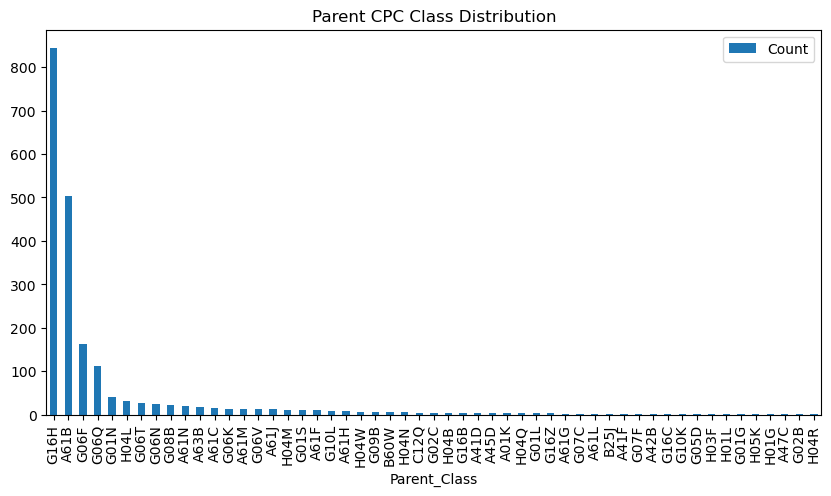

In [50]:
parent_df = pd.DataFrame(
    parent_count.items(),
    columns=['Parent_Class', 'Count']
)

parent_df.sort_values('Count', ascending=False)\
         .plot(x='Parent_Class',
               y='Count',
               kind='bar',
               figsize=(10,5))

plt.title('Parent CPC Class Distribution')
plt.show()

### subcategory distribution

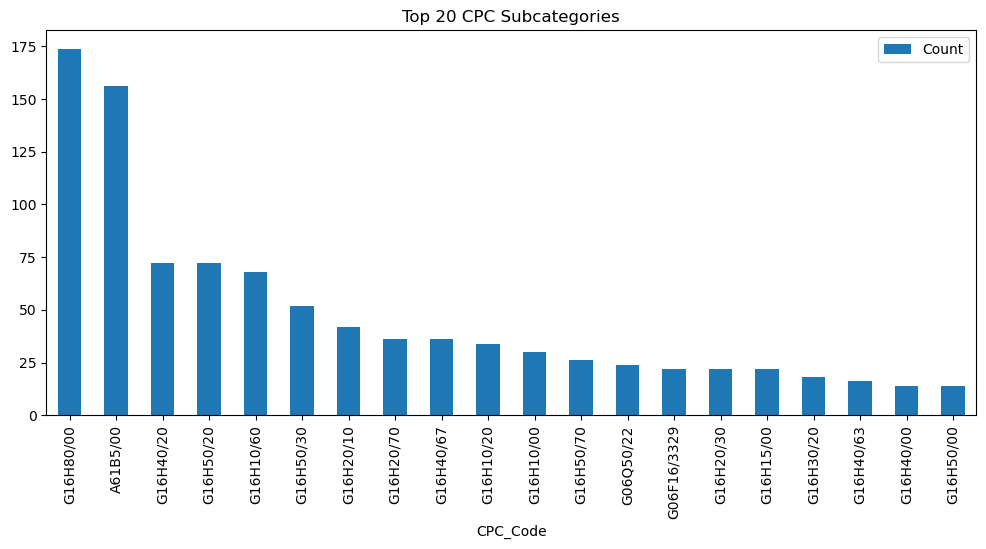

In [51]:
top_sub = pd.DataFrame(
    subclass_count.most_common(20),
    columns=['CPC_Code', 'Count']
)

top_sub.plot(x='CPC_Code',
             y='Count',
             kind='bar',
             figsize=(12,5))

plt.title('Top 20 CPC Subcategories')
plt.show()